In [43]:
import nltk
from nltk.corpus import stopwords
import string
from wordcloud import WordCloud
import zipfile
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import RegexpTokenizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

f = open("A4_question2a_data.txt").read()

#Question 1
words= nltk.word_tokenize(f)
sentences= nltk.sent_tokenize(f)
counter_king=0
word_length=[]
sentence_length=[]

for w in words:
    word_length.append(len(w))
    
for s in sentences:
    sentence_length.append(len(s))

print('Average word length is:',int(sum(word_length)/len(word_length)))
print('Average sentence length is:',int(sum(sentence_length)/len(sentence_length)))

regex_tok=RegexpTokenizer(r'\w+')
words1=regex_tok.tokenize(f)

for w in words1:
    if(str.lower(w)=='king'):
        counter_king=counter_king+1

print('The number of times \'king\' appears(case insensitive, with punctuations) is:',counter_king)



Average word length is: 3
Average sentence length is: 67
The number of times 'king' appears(case insensitive, with punctuations) is: 55


In [44]:
#Question 2

with zipfile.ZipFile("A4_Question2b_data.zip") as zip:
    with zip.open("A4_Question2b_data/D1.txt") as fp:
        file1=fp.read().decode()
    with zip.open("A4_Question2b_data/D2.txt") as fp:
        file2=fp.read().decode()
    zip.close()   

stopwords_list = stopwords.words('english')
#Add older words to stopwords list
stopwords_list += ['art', 'doth', 'dost', 'ere', 'ere', 'hast', 'hath',
                   'hence', 'hither', 'nigh', 'oft', 'shouldst', 'thither',
                   'thee', 'thou', 'thine', 'thy', 'tis', 'twas', 'wast',
                   'whence', 'wherefore', 'whereto', 'withal', 'wouldst',
                   'ye', 'yon', 'yonder', 'th','and','the']
#Add punctuation to stopwords list
stopwords_list += list(string.punctuation)    

for s in stopwords_list:
    s=str.lower(s)

files=[file1,file2]
documents=[]

for d in files:
    final_str=""
    words=regex_tok.tokenize(d)
    for word in words:
        if (str.lower(word) not in stopwords_list):
            final_str=final_str+" "+str(word)
    documents.append(final_str)

vec=TfidfVectorizer()
matrix=vec.fit_transform(documents)
feature_names = vec.get_feature_names()
dense = matrix.todense()
lst = dense.tolist()
df = pd.DataFrame(lst,columns=feature_names)
df

,1603,abhor,abhorred,abide,abiure,able,aboue,abound,abroad,absence,...,yoake,yong,yore,youl,young,youngly,youth,youthful,youths,zealous
0,0.002788,0.000000,0.002788,0.003968,0.002788,0.000000,0.008365,0.002788,0.005576,0.003968,...,0.002788,0.011153,0.000000,0.002788,0.007935,0.000000,0.001984,0.000000,0.002788,0.000000
1,0.000000,0.006201,0.000000,0.004412,0.000000,0.003101,0.000000,0.000000,0.000000,0.011031,...,0.000000,0.000000,0.003101,0.000000,0.008824,0.003101,0.035298,0.006201,0.000000,0.003101


In [45]:
df=df.transpose().sum(axis=1)
df=pd.DataFrame(df)
df.index.name='term'
df.columns = ['tfidf']
df.sort_values(by=['tfidf'],inplace=True,ascending=False)
#write df to a csv
df.to_csv('term_tfidf.csv')
print('Term-tf-idf scores have been written to CSV!')

Term-tf-idf scores have been written to CSV!


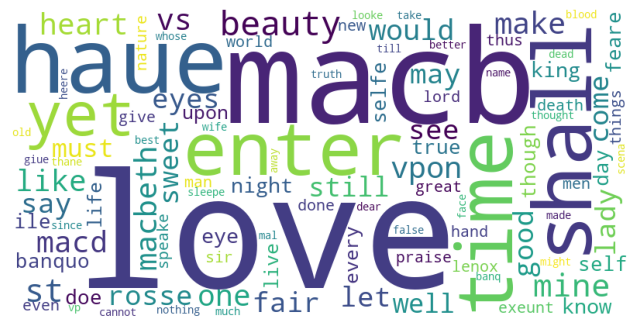

In [46]:
cld=pd.read_csv('term_tfidf.csv')
data = cld.set_index('term').to_dict()['tfidf']
#display only top 100 words
wct = WordCloud(background_color="white",width=800, height=400, max_words=100).generate_from_frequencies(data)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(wct)
plt.show()